Total number of features: 8404

Alpha = 0.01
Non-zero coefficients: 417
Eliminated features: 7987

Alpha = 0.1
Non-zero coefficients: 341
Eliminated features: 8063

Alpha = 1
Non-zero coefficients: 100
Eliminated features: 8304

Feature Reduction Percentage (alpha=0.1): 95.94240837696336


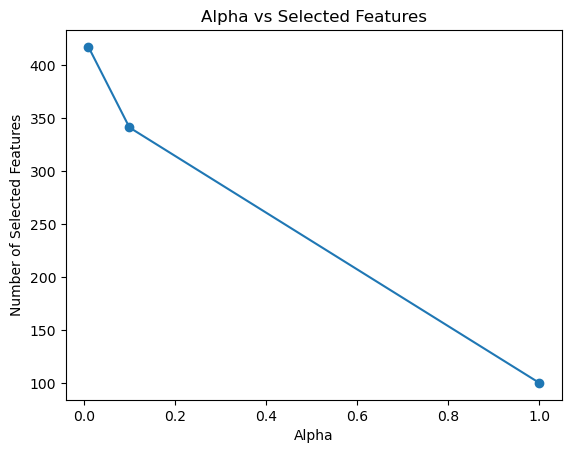

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

df = pd.read_csv("spam.csv", encoding='latin-1')

df = df[['v1', 'v2']]
df.columns = ['label', 'message']

df['label'] = df['label'].map({'ham': 0, 'spam': 1})

vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['message'])

total_features = X.shape[1]
print("Total number of features:", total_features)

y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

def train_lasso(alpha):
    model = LogisticRegression(penalty='l1', solver='liblinear', C=1/alpha, max_iter=5000)
    model.fit(X_train, y_train)

    coef = model.coef_[0]

    non_zero = np.sum(coef != 0)
    zero = np.sum(coef == 0)

    print("\nAlpha =", alpha)
    print("Non-zero coefficients:", non_zero)
    print("Eliminated features:", zero)

    return non_zero

features_001 = train_lasso(0.01)
features_01 = train_lasso(0.1)
features_1 = train_lasso(1)

reduction = ((total_features - features_01) / total_features) * 100
print("\nFeature Reduction Percentage (alpha=0.1):", reduction)

alphas = [0.01, 0.1, 1]
features = [features_001, features_01, features_1]

plt.figure()
plt.plot(alphas, features, marker='o')
plt.xlabel("Alpha")
plt.ylabel("Number of Selected Features")
plt.title("Alpha vs Selected Features")
plt.show()